In [1]:
import pandas as pd
import numpy as np
%matplotlib inline
     

In [165]:
df_movies.columns =['MovieID','MovieName','Genre']

df_movies = pd.read_csv('./movie_rating/movies.utf.csv',sep='::', engine='python', names=df_movies.columns)
df_movies.head()

,MovieID,MovieName,Genre
0,1,Toy Story (1995),"Animation|Children's|Comedy,,"
1,2,Jumanji (1995),"Adventure|Children's|Fantasy,,"
2,3,Grumpier Old Men (1995),"Comedy|Romance,,"
3,4,Waiting to Exhale (1995),"Comedy|Drama,,"
4,5,Father of the Bride Part II (1995),"Comedy,,"


In [31]:
import pandas as pd

# Define column names since the dataset doesn't have headers
df_ratings.columns = ["UserID", "MovieID", "Rating", "Timestamp"]

# Read CSV with correct separator and column names
df_ratings = pd.read_csv('./movie_rating/ratings.utf.csv', sep='::', engine='python', names=df_ratings.columns)

# Display first few rows
df_ratings.head()


,UserID,MovieID,Rating,Timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291


In [13]:
#df_ratings.to_csv('./movie_rating/ratings.utf.csv', sep='::', index=False, header=True)


In [35]:
import pandas as pd

# Define column names for users dataset
df_users.columns = ["UserID", "Gender", "Age", "Occupation", "Zip-code"]

# Read CSV with correct separator and column names
df_users = pd.read_csv('./movie_rating/users.utf.csv', sep='::', engine='python', names=df_users.columns)

# Display first few rows
df_users.head()


,UserID,Gender,Age,Occupation,Zip-code
0,1,F,1,10,48067
1,2,M,56,16,70072
2,3,M,25,15,55117
3,4,M,45,7,02460
4,5,M,25,20,55455


In [37]:

df_movies.isnull().sum()

MovieID      0
MovieName    0
Genre        0
dtype: int64

In [39]:

df_ratings.isnull().sum()

UserID       0
MovieID      0
Rating       0
Timestamp    0
dtype: int64

In [41]:

df_users.isnull().sum()

UserID        0
Gender        0
Age           0
Occupation    0
Zip-code      0
dtype: int64

In [43]:
user_ratings = pd.merge(df_ratings,df_users, on = ['UserID', 'UserID'])
user_ratings.head()


,UserID,MovieID,Rating,Timestamp,Gender,Age,Occupation,Zip-code
0,1,1193,5,978300760,F,1,10,48067
1,1,661,3,978302109,F,1,10,48067
2,1,914,3,978301968,F,1,10,48067
3,1,3408,4,978300275,F,1,10,48067
4,1,2355,5,978824291,F,1,10,48067


In [45]:
movie_ratings = df_movies.merge(user_ratings, on =['MovieID'])
movie_ratings.head()

,MovieID,MovieName,Genre,UserID,Rating,Timestamp,Gender,Age,Occupation,Zip-code
0,1,Toy Story (1995),"Animation|Children's|Comedy,,",1,5,978824268,F,1,10,48067
1,1,Toy Story (1995),"Animation|Children's|Comedy,,",6,4,978237008,F,50,9,55117
2,1,Toy Story (1995),"Animation|Children's|Comedy,,",8,4,978233496,M,25,12,11413
3,1,Toy Story (1995),"Animation|Children's|Comedy,,",9,5,978225952,M,25,17,61614
4,1,Toy Story (1995),"Animation|Children's|Comedy,,",10,5,978226474,F,35,1,95370


In [47]:
movie_ratings.info()
     

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000209 entries, 0 to 1000208
Data columns (total 10 columns):
 #   Column      Non-Null Count    Dtype 
---  ------      --------------    ----- 
 0   MovieID     1000209 non-null  int64 
 1   MovieName   1000209 non-null  object
 2   Genre       1000209 non-null  object
 3   UserID      1000209 non-null  int64 
 4   Rating      1000209 non-null  int64 
 5   Timestamp   1000209 non-null  int64 
 6   Gender      1000209 non-null  object
 7   Age         1000209 non-null  int64 
 8   Occupation  1000209 non-null  int64 
 9   Zip-code    1000209 non-null  object
dtypes: int64(6), object(4)
memory usage: 76.3+ MB


In [ ]:
# Exploring the dataset

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns
import random as rnd

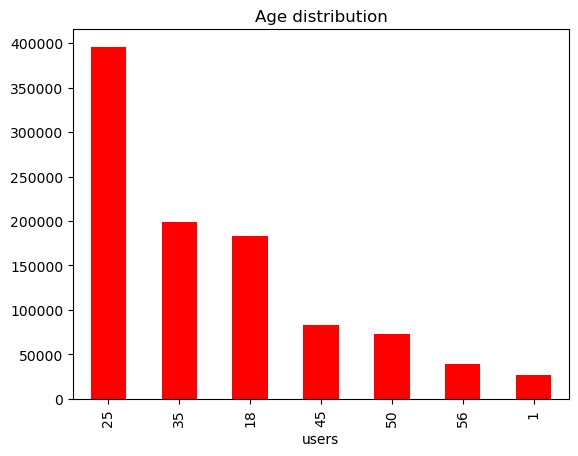

In [51]:
# exploring the users age distribution
movie_ratings['Age'].value_counts().plot(color = 'red', kind = 'bar', title='Age distribution', xlabel='users')
plt.show()
     

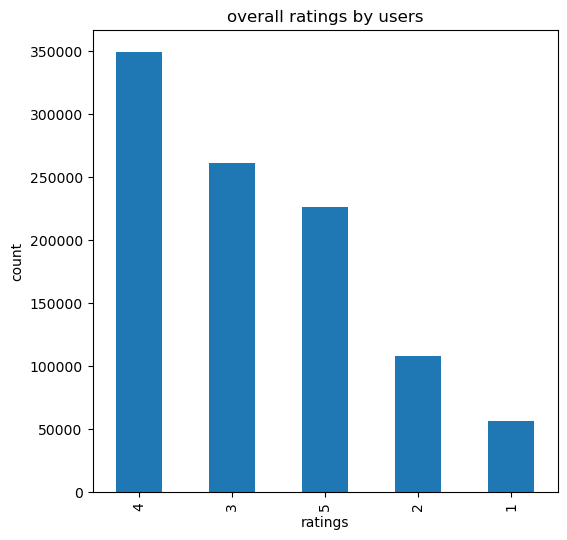

In [55]:
# Overall ratings by users
movie_ratings['Rating'].value_counts().plot(kind='bar',figsize=(6,6), title= 'overall ratings by users', ylabel='count', xlabel='ratings' )
plt.show()


In [59]:
# using group by to get the unique values of the data
users = movie_ratings.groupby('UserID')
ratings = movie_ratings.groupby('Rating')
movies = movie_ratings.groupby('MovieName')
movies.first()

,MovieID,Genre,UserID,Rating,Timestamp,Gender,Age,Occupation,Zip-code
MovieName,,,,,,,,,
"$1,0,000 Duck (1971)",2031,Children's|Comedy,216,2,976867230,M,45,13,52761
'Night Mother (1986),3112,"Drama,,",68,5,977883710,M,18,4,53706
'Til There Was You (1997),779,"Drama|Romance,,",38,2,978045250,F,18,4,02215
"'burbs, The (1989)",2072,"Comedy,",10,4,978230923,F,35,1,95370
...And Justice for All (1979),3420,"Drama|Thriller,,",23,2,978465796,M,35,0,90049
...,...,...,...,...,...,...,...,...,...
"Zed & Two Noughts, A (1985)",3223,"Drama,",655,2,975698249,F,25,2,92629
Zero Effect (1998),1845,"Comedy|Thriller,,",23,3,978465462,M,35,0,90049
Zero Kelvin (Kjærlighetens kjøtere) (1995),1364,"Action,,",1352,3,1031532546,M,35,20,94122


In [61]:
# getting info about toy story
toy_story2= movies.get_group('Toy Story 2 (1999)')
toy_story2

,MovieID,MovieName,Genre,UserID,Rating,Timestamp,Gender,Age,Occupation,Zip-code
836694,3114,Toy Story 2 (1999),"Animation|Children's|Comedy,,",1,4,978302174,F,1,10,48067
836695,3114,Toy Story 2 (1999),"Animation|Children's|Comedy,,",3,3,978298103,M,25,15,55117
836696,3114,Toy Story 2 (1999),"Animation|Children's|Comedy,,",9,4,978225952,M,25,17,61614
836697,3114,Toy Story 2 (1999),"Animation|Children's|Comedy,,",10,4,978225759,F,35,1,95370
836698,3114,Toy Story 2 (1999),"Animation|Children's|Comedy,,",17,5,978159386,M,50,1,95350
...,...,...,...,...,...,...,...,...,...,...
838274,3114,Toy Story 2 (1999),"Animation|Children's|Comedy,,",6022,5,956755741,M,25,17,57006
838275,3114,Toy Story 2 (1999),"Animation|Children's|Comedy,,",6024,4,956749447,M,25,12,53705
838276,3114,Toy Story 2 (1999),"Animation|Children's|Comedy,,",6027,4,956726766,M,18,4,20742
838277,3114,Toy Story 2 (1999),"Animation|Children's|Comedy,,",6036,4,956710231,F,25,15,32603


In [63]:

# creating a new categorial variable age group from existing numerical variable age using pd.cut funtion
labels = ['1-10','10-20','20-30','30-40','40-50','50-60','60-70']
movie_ratings['age_group']= pd.cut(movie_ratings.Age, range(0,81,11), right=False, labels = labels)
movie_ratings[['Age','age_group']].drop_duplicates()

,Age,age_group
0,1,1-10
1,50,40-50
2,25,20-30
4,35,30-40
5,18,10-20
14,45,40-50
27,56,50-60


In [65]:
movie_ratings['age_group']

0           1-10
1          40-50
2          20-30
3          20-30
4          30-40
           ...  
1000204    20-30
1000205    20-30
1000206    20-30
1000207    30-40
1000208    10-20
Name: age_group, Length: 1000209, dtype: category
Categories (7, object): ['1-10' < '10-20' < '20-30' < '30-40' < '40-50' < '50-60' < '60-70']

<Axes: xlabel='Movie Name'>

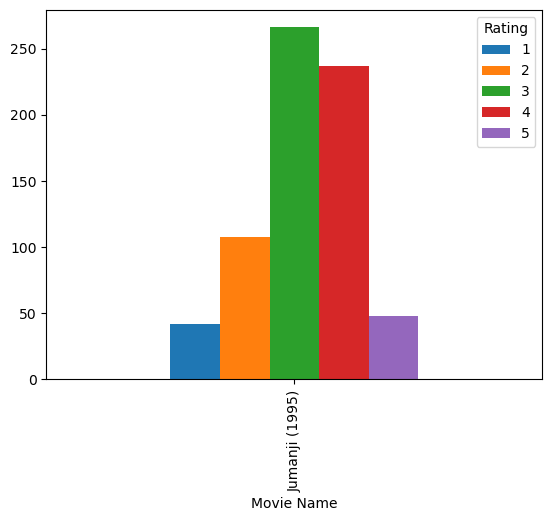

In [69]:
# Jumanji movie ratings
JJRatings = movie_ratings[movie_ratings['MovieName'].str.contains('Jumanji')==True]
JJRatings.groupby(['MovieName','Rating']).size().unstack().plot(kind='bar', stacked=False, xlabel= 'Movie Name')

/var/folders/hv/dp8jhq_d559481ghvqg20r700000gn/T/ipykernel_29990/1385497285.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  JJRatings.groupby(['MovieName','age_group']).size().unstack().plot(kind='barh')


<Axes: ylabel='MovieName'>

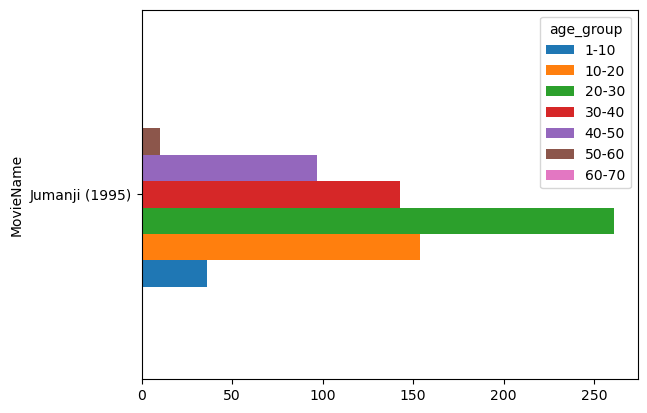

In [75]:
# we can visualize the age group that views jumanji
JJRatings.groupby(['MovieName','age_group']).size().unstack().plot(kind='barh')

In [77]:
movies = movie_ratings.groupby('MovieName')

In [79]:
movies.first()

,MovieID,Genre,UserID,Rating,Timestamp,Gender,Age,Occupation,Zip-code,age_group
MovieName,,,,,,,,,,
"$1,0,000 Duck (1971)",2031,Children's|Comedy,216,2,976867230,M,45,13,52761,40-50
'Night Mother (1986),3112,"Drama,,",68,5,977883710,M,18,4,53706,10-20
'Til There Was You (1997),779,"Drama|Romance,,",38,2,978045250,F,18,4,02215,10-20
"'burbs, The (1989)",2072,"Comedy,",10,4,978230923,F,35,1,95370,30-40
...And Justice for All (1979),3420,"Drama|Thriller,,",23,2,978465796,M,35,0,90049,30-40
...,...,...,...,...,...,...,...,...,...,...
"Zed & Two Noughts, A (1985)",3223,"Drama,",655,2,975698249,F,25,2,92629,20-30
Zero Effect (1998),1845,"Comedy|Thriller,,",23,3,978465462,M,35,0,90049,30-40
Zero Kelvin (Kjærlighetens kjøtere) (1995),1364,"Action,,",1352,3,1031532546,M,35,20,94122,30-40


In [83]:
# finding movie with rtaings more than three
rat =  movie_ratings[movie_ratings['Rating']>3]
r = rat.groupby('MovieName')
r.first()

,MovieID,Genre,UserID,Rating,Timestamp,Gender,Age,Occupation,Zip-code,age_group
MovieName,,,,,,,,,,
"$1,0,000 Duck (1971)",2031,Children's|Comedy,494,5,976215651,F,35,0,17870,30-40
'Night Mother (1986),3112,"Drama,,",68,5,977883710,M,18,4,53706,10-20
'Til There Was You (1997),779,"Drama|Romance,,",156,4,977250462,F,45,7,14519,40-50
"'burbs, The (1989)",2072,"Comedy,",10,4,978230923,F,35,1,95370,30-40
...And Justice for All (1979),3420,"Drama|Thriller,,",146,5,979854434,F,35,20,10954,30-40
...,...,...,...,...,...,...,...,...,...,...
"Zed & Two Noughts, A (1985)",3223,"Drama,",850,5,975351151,M,35,0,60640,30-40
Zero Effect (1998),1845,"Comedy|Thriller,,",53,5,977973989,M,25,0,96931,20-30
Zero Kelvin (Kjærlighetens kjøtere) (1995),1364,"Action,,",4277,4,1000961159,M,35,16,98133,30-40


In [85]:
# finding out all the genres
dfGenres = movie_ratings['Genre'].str.split('|')
dfGenres

0          [Animation, Children's, Comedy,,]
1          [Animation, Children's, Comedy,,]
2          [Animation, Children's, Comedy,,]
3          [Animation, Children's, Comedy,,]
4          [Animation, Children's, Comedy,,]
                         ...                
1000204                   [Drama, Thriller,]
1000205                   [Drama, Thriller,]
1000206                   [Drama, Thriller,]
1000207                   [Drama, Thriller,]
1000208                   [Drama, Thriller,]
Name: Genre, Length: 1000209, dtype: object

In [87]:
listgenre = set()
for genre in dfGenres:
  listgenre = listgenre.union(set(genre))

In [89]:
listgenre

{'Action',
 'Action,',
 'Action,,',
 'Adventure',
 'Adventure,',
 'Adventure,,',
 'Animation',
 'Animation,',
 'Animation,,',
 "Children's",
 "Children's,",
 "Children's,,",
 'Comedy',
 'Comedy,',
 'Comedy,,',
 'Crime',
 'Crime,',
 'Crime,,',
 'Documentary',
 'Documentary,',
 'Documentary,,',
 'Drama',
 'Drama,',
 'Drama,,',
 'Fantasy',
 'Fantasy,',
 'Fantasy,,',
 'Film-Noir',
 'Film-Noir,',
 'Film-Noir,,',
 'Horror',
 'Horror,',
 'Horror,,',
 'Musical',
 'Musical,',
 'Musical,,',
 'Mystery',
 'Mystery,',
 'Mystery,,',
 'Romance',
 'Romance,',
 'Romance,,',
 'Sci-Fi',
 'Sci-Fi,',
 'Sci-Fi,,',
 'Thriller',
 'Thriller,',
 'Thriller,,',
 'War',
 'War,',
 'War,,',
 'Western',
 'Western,',
 'Western,,'}

In [91]:
# Creating a separate for each type of genre with one hot encoding(0 or 1), whether or not the movie belongs to that category
ratings01=movie_ratings['Genre'].str.get_dummies('|')
ratings01= ratings01.drop_duplicates()
ratings01.head()

,Action,"Action,","Action,,",Adventure,"Adventure,","Adventure,,",Animation,"Animation,","Animation,,",Children's,...,"Sci-Fi,,",Thriller,"Thriller,","Thriller,,",War,"War,","War,,",Western,"Western,","Western,,"
0,0,0,0,0,0,0,1,0,0,1,...,0,0,0,0,0,0,0,0,0,0
2077,0,0,0,1,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
2778,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3256,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3426,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


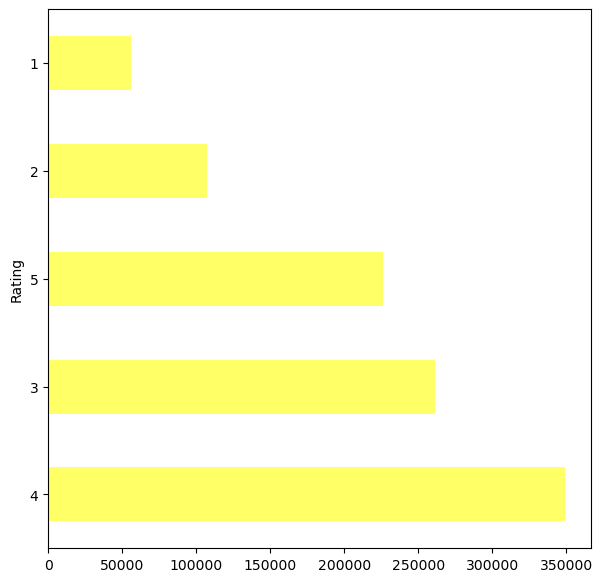

In [95]:
#Find and visualize the top 25 movies by viewership rating
top_25 = movie_ratings[25:]
top_25['Rating'].value_counts().plot(kind='barh',alpha=0.6,figsize=(7,7),color='yellow')
plt.show()
     

In [97]:

#finding factors/features that affect the rating of a movie
movie_ratings.groupby('Gender').size().sort_values(ascending=False)

Gender
M    753769
F    246440
dtype: int64

<Axes: xlabel='Age'>

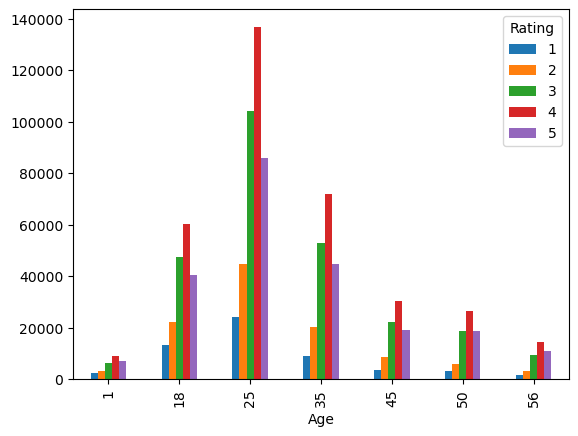

In [99]:
movie_ratings.groupby(['Age','Rating']).size().unstack().plot(kind='bar', stacked=False)

<Axes: xlabel='Gender'>

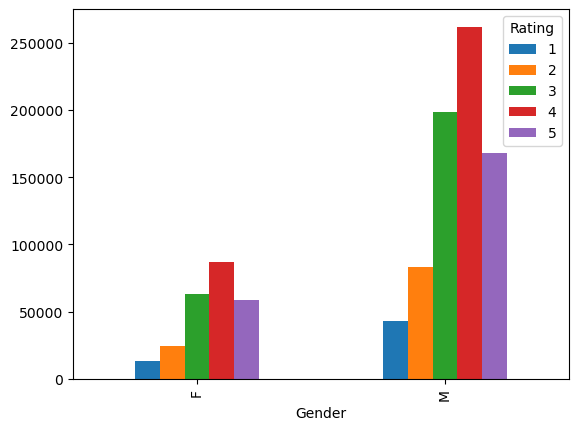

In [101]:
movie_ratings.groupby(['Gender','Rating']).size().unstack().plot(kind='bar', stacked=False)

In [ ]:
#Model development and training

In [103]:
#separating the feature and target variable
features = movie_ratings[['MovieID','Age','Occupation']].values
labels= movie_ratings['Rating'].values

In [105]:
# import necessary dependencies for training and modeling of your data
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics

In [107]:

# splitting the dataset into trining and testing data
train, test, train_labels, test_labels = train_test_split(features, labels, test_size=0.3)

In [109]:
# Model 1
lr = LogisticRegression()
lr.fit(train,train_labels)
y_predict= lr.predict(test)
acc_model1 = accuracy_score(test_labels, y_predict)
score1 = round(lr.score(train, train_labels)*100,2)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [111]:
score1

34.89

In [113]:
Classification_Report = classification_report(test_labels, y_predict)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [115]:
print('accuracy score of Logistic Regression model is :', acc_model1)
print('score of Logistic Regression model is :', score1)
print('classification report of Logistic Regression model is :', Classification_Report)

accuracy score of Logistic Regression model is : 0.3488800685189444
score of Logistic Regression model is : 34.89
classification report of Logistic Regression model is :               precision    recall  f1-score   support

           1       0.00      0.00      0.00     16923
           2       0.00      0.00      0.00     32387
           3       0.00      0.00      0.00     78166
           4       0.35      1.00      0.52    104686
           5       0.00      0.00      0.00     67901

    accuracy                           0.35    300063
   macro avg       0.07      0.20      0.10    300063
weighted avg       0.12      0.35      0.18    300063



In [117]:
# Model 2
rf = RandomForestClassifier(n_estimators=100)
rf.fit(train,train_labels)
y_pred_rf= rf.predict(test)
acc_model2 = accuracy_score(test_labels, y_pred_rf)
score2 = round(rf.score(train, train_labels)*100,2)

In [118]:
Classification_Report = classification_report(test_labels, y_pred_rf)

In [119]:
print('score of  Random Forest model is :', score2)
print('classification report of Random Forest model is :', Classification_Report)

score of  Random Forest model is : 56.16
classification report of Random Forest model is :               precision    recall  f1-score   support

           1       0.25      0.15      0.19     16923
           2       0.21      0.13      0.16     32387
           3       0.32      0.30      0.31     78166
           4       0.39      0.47      0.43    104686
           5       0.39      0.39      0.39     67901

    accuracy                           0.35    300063
   macro avg       0.31      0.29      0.30    300063
weighted avg       0.34      0.35      0.35    300063



In [123]:
score2

56.16

In [125]:
# Model 3
knn = KNeighborsClassifier()
knn.fit(train,train_labels)
y_pred_knn= knn.predict(test)
acc_model3 = accuracy_score(test_labels, y_pred_knn)
score3 = round(knn.score(train, train_labels)*100,2)
     


In [127]:
Classification_Report = classification_report(test_labels, y_pred_knn)

In [129]:

print('accuracy score of KNN model is :', acc_model3)
print('score of  KNN model is :', score3)
print('classification report of KNN model is :', Classification_Report)

accuracy score of KNN model is : 0.33427646860825894
score of  KNN model is : 46.43
classification report of KNN model is :               precision    recall  f1-score   support

           1       0.21      0.19      0.20     16923
           2       0.19      0.16      0.18     32387
           3       0.30      0.36      0.33     78166
           4       0.38      0.43      0.40    104686
           5       0.39      0.29      0.33     67901

    accuracy                           0.33    300063
   macro avg       0.30      0.28      0.29    300063
weighted avg       0.33      0.33      0.33    300063



In [131]:
score3

46.43

In [135]:
models = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest Classifier', 'K-Nearest Neighbor'],
    'Score': [score1, score2, score3]
})

In [137]:
models.sort_values(ascending=False, by='Score')

,Model,Score
1,Random Forest Classifier,56.16
2,K-Nearest Neighbor,46.43
0,Logistic Regression,34.89


In [139]:
# let'spredict some values now
print(train)

[[ 915   50   16]
 [2533   25    7]
 [1029   18    0]
 ...
 [3253   18    3]
 [1580   25    7]
 [2011   45    0]]


In [141]:
print(labels)

[5 4 4 ... 4 1 4]


In [143]:
rf.predict([[1150, 45, 1]])

array([4])

In [145]:
# Making predictions
y_pred_rf = rf.predict(test)

# Evaluating the model
acc_model2 = accuracy_score(test_labels, y_pred_rf)
score2 = round(rf.score(train, train_labels) * 100, 2)
classification_rep = classification_report(test_labels, y_pred_rf)

# Displaying results
print('Accuracy score of Random Forest model:', acc_model2)
print('Training score of Random Forest model:', score2)
print('Classification report of Random Forest model:\n', classification_rep)

# Creating a DataFrame to store model scores
models = pd.DataFrame({
    'Model': ['Random Forest Classifier'],
    'Accuracy Score': [acc_model2],
    'Training Score': [score2]
})

print(models)

Accuracy score of Random Forest model: 0.35401232407861016
Training score of Random Forest model: 56.16
Classification report of Random Forest model:
               precision    recall  f1-score   support

           1       0.25      0.15      0.19     16923
           2       0.21      0.13      0.16     32387
           3       0.32      0.30      0.31     78166
           4       0.39      0.47      0.43    104686
           5       0.39      0.39      0.39     67901

    accuracy                           0.35    300063
   macro avg       0.31      0.29      0.30    300063
weighted avg       0.34      0.35      0.35    300063

                      Model  Accuracy Score  Training Score
0  Random Forest Classifier        0.354012           56.16


In [147]:
import numpy as np
import pandas as pd

# Example test case (replace with actual values)
sample_data = np.array([[123, 25, 3]])  # MovieID=123, Age=25, Occupation=3

# Ensure the input shape matches the model's expectation
sample_data = sample_data.reshape(1, -1)


In [149]:
prediction = rf.predict(sample_data)
print("Predicted Rating:", prediction[0])


Predicted Rating: 1


In [151]:
prediction_prob = rf.predict_proba(sample_data)
print("Prediction Probabilities:", prediction_prob)


Prediction Probabilities: [[0.48366667 0.10369697 0.         0.35633333 0.05630303]]


In [153]:
multiple_samples = np.array([[123, 25, 3], [456, 30, 7]])
predictions = rf.predict(multiple_samples)
print("Predicted Ratings:", predictions)


Predicted Ratings: [1 4]


In [173]:
user_age = 30  # Example age
user_occupation = 5  # Example occupation
# Get all unique MovieIDs
all_movies = movie_ratings['MovieID'].unique()

# Get movies the user has already rated
rated_movies = movie_ratings[movie_ratings['Age'] == user_age]['MovieID'].unique()

# Filter movies the user hasn't seen
unrated_movies = np.setdiff1d(all_movies, rated_movies)


In [175]:
recommendations = []

for movie in unrated_movies:
    sample_data = np.array([[movie, user_age, user_occupation]])  # Format the input
    predicted_rating = rf.predict(sample_data)[0]  # Predict the rating
    recommendations.append((movie, predicted_rating))  # Store the result


In [176]:
# Sort by rating (highest first)
recommendations.sort(key=lambda x: x[1], reverse=True)

# Get the top 5 movies
top_movies = recommendations[:5]

# Display results
print("Recommended Movies:")
for movie, rating in top_movies:
    print(f"Movie ID: {movie}, Predicted Rating: {rating}")


Recommended Movies:
Movie ID: 1, Predicted Rating: 5
Movie ID: 14, Predicted Rating: 5
Movie ID: 15, Predicted Rating: 5
Movie ID: 17, Predicted Rating: 5
Movie ID: 21, Predicted Rating: 5


In [177]:
# Create a DataFrame with MovieID and Predicted Ratings
top_movies_df = pd.DataFrame(top_movies, columns=['MovieID', 'Predicted Rating'])

# Merge with df_movies to get Movie Titles
top_movies_df = top_movies_df.merge(df_movies[['MovieID', 'MovieName']], on='MovieID', how='left')

# Display the results
print(top_movies_df[['MovieName', 'Predicted Rating']])


                      MovieName  Predicted Rating
0              Toy Story (1995)                 5
1                  Nixon (1995)                 5
2       Cutthroat Island (1995)                 5
3  Sense and Sensibility (1995)                 5
4             Get Shorty (1995)                 5


In [ ]:
                  MovieName  Predicted Rating
0   Shadows (Cienie) (1988)                 5
1  Nemesis 2: Nebula (1995)                 5
2         Rent-a-Kid (1995)                 5
3          Fall Time (1995)                 5
4    Frank and Ollie (1995)                 5